# Introduction
Shah Rukh Khan, also known by the initialism SRK, is an Indian actor and film producer who works in Hindi cinema. Referred to in the media as the "Baadshah of Bollywood" and "King Khan", he has appeared in more than 100 films, and earned numerous accolades, including 14 Filmfare Awards.

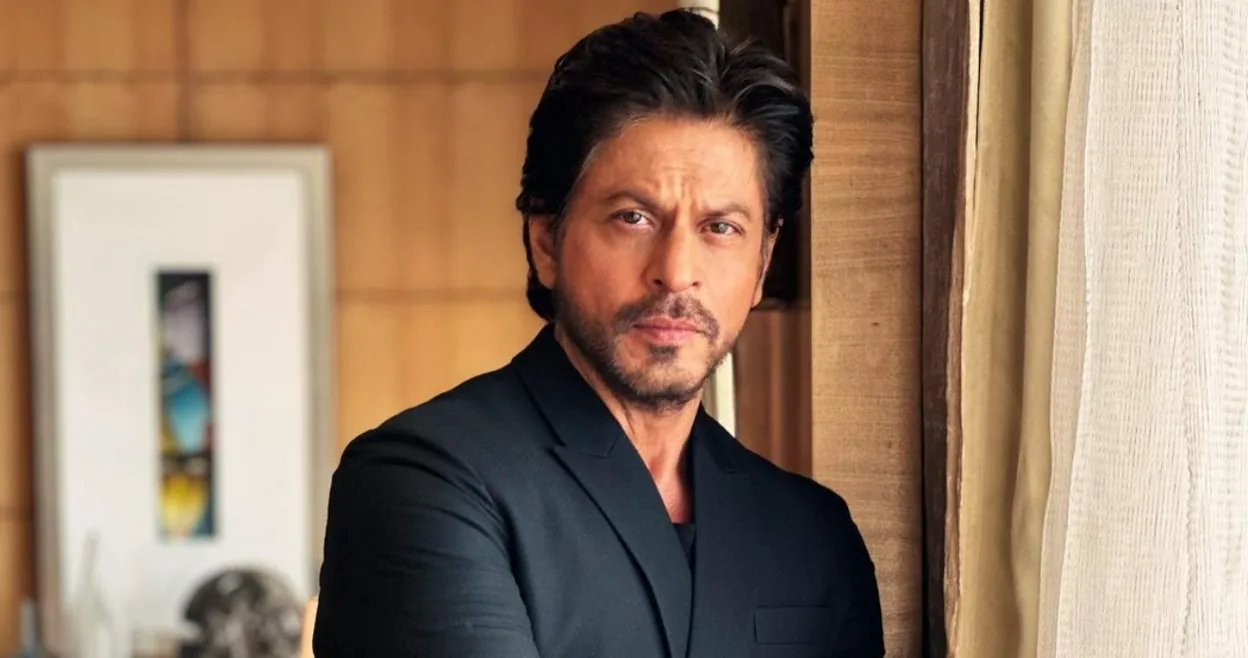

This GPT model is fine-tuned version of gemma 2 with SRK witty comments response dataset available from Hugging Face (abhishek-mungoli/srk_wittiness)
There is also a custom-made chat template for user and SRK responses.
The model is named **Ask-ShahRukh GPT**

# Installation

In [1]:
# Suppress output for cleaner notebook (using context manager instead of %%capture)
import os
from IPython.utils import io

with io.capture_output() as captured:
    # Install required packages
    !pip install unsloth vllm
    !pip install --no-deps bitsandbytes accelerate xformers==0.0.29.post3 peft trl triton
    !pip install sentencepiece protobuf datasets huggingface_hub hf_transfer

    # vLLM-specific requirements (avoiding conflicts with pre-installed packages)
    import requests
    import re
    f = requests.get("https://raw.githubusercontent.com/vllm-project/vllm/refs/heads/main/requirements/common.txt").content
    with open("vllm_requirements.txt", "wb") as file:
        file.write(re.sub(rb"(transformers|numpy|xformers)[^\n]{1,}\n", b"", f))
    !pip install -r vllm_requirements.txt

# Optional: Check if installations worked
print("Installation complete!")

Installation complete!


# Unsloth
FastModel supports loading nearly any model now! This includes Vision and Text models!

In [2]:
from unsloth import FastLanguageModel
import torch
max_seq_length = 2048 # Choose any! We auto support RoPE Scaling internally!
dtype = None # None for auto detection. Float16 for Tesla T4, V100, Bfloat16 for Ampere+
load_in_4bit = True # Use 4bit quantization to reduce memory usage. Can be False.

# 4bit pre quantized models we support for 4x faster downloading + no OOMs.
fourbit_models = [
    "unsloth/Meta-Llama-3.1-8B-bnb-4bit",      # Llama-3.1 2x faster
    "unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit",
    "unsloth/Meta-Llama-3.1-70B-bnb-4bit",
    "unsloth/Meta-Llama-3.1-405B-bnb-4bit",    # 4bit for 405b!
    "unsloth/Mistral-Small-Instruct-2409",     # Mistral 22b 2x faster!
    "unsloth/mistral-7b-instruct-v0.3-bnb-4bit",
    "unsloth/Phi-3.5-mini-instruct",           # Phi-3.5 2x faster!
    "unsloth/Phi-3-medium-4k-instruct",
    "unsloth/gemma-2-9b-bnb-4bit",
    "unsloth/gemma-2-27b-bnb-4bit",            # Gemma 2x faster!

    "unsloth/Llama-3.2-1B-bnb-4bit",           # NEW! Llama 3.2 models
    "unsloth/Llama-3.2-1B-Instruct-bnb-4bit",
    "unsloth/Llama-3.2-3B-bnb-4bit",
    "unsloth/Llama-3.2-3B-Instruct-bnb-4bit",

    "unsloth/Llama-3.3-70B-Instruct-bnb-4bit" # NEW! Llama 3.3 70B!
] # More models at https://huggingface.co/unsloth

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Llama-3.2-3B-Instruct", # or choose "unsloth/Llama-3.2-1B-Instruct"
    max_seq_length = max_seq_length,
    dtype = dtype,
    load_in_4bit = load_in_4bit,
    # token = "hf_...", # use one if using gated models like meta-llama/Llama-2-7b-hf
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


2025-04-14 23:04:06.007255: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744671846.193563      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744671846.247486      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Unsloth: Failed to patch Gemma3ForConditionalGeneration.
🦥 Unsloth Zoo will now patch everything to make training faster!
INFO 04-14 23:04:24 [__init__.py:239] Automatically detected platform cuda.
==((====))==  Unsloth 2025.3.19: Fast Llama patching. Transformers: 4.51.1. vLLM: 0.8.3.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 7.5. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.29.post3. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.35G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/54.7k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

We now add LoRA adapters so we only need to update 1 to 10% of all parameters!

In [3]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 16, # Choose any number > 0 ! Suggested 8, 16, 32, 64, 128
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj",],
    lora_alpha = 16,
    lora_dropout = 0, # Supports any, but = 0 is optimized
    bias = "none",    # Supports any, but = "none" is optimized
    # [NEW] "unsloth" uses 30% less VRAM, fits 2x larger batch sizes!
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for very long context
    random_state = 3407,
    use_rslora = False,  # We support rank stabilized LoRA
    loftq_config = None, # And LoftQ
)

Unsloth 2025.3.19 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


Data Prep
We now use the Llama-3.1 format for conversation style finetunes. We use Maxime Labonne's FineTome-100k dataset in ShareGPT style. But we convert it to HuggingFace's normal multiturn format ("role", "content") instead of ("from", "value")/ Llama-3 renders multi turn conversations like below:


> <|begin_of_text|><|start_header_id|>user<|end_header_id|>Hello!<|eot_id|><|start_header_id|>assistant<|end_header_id|>Hey there! How are you?<|eot_id|><|start_header_id|>user<|end_header_id|>I'm great thanks!<|eot_id|>


In [4]:
# Load and format dataset
from datasets import load_dataset
from unsloth.chat_templates import get_chat_template
import logging

# Suppress logs to avoid clutter
logging.getLogger().setLevel(logging.ERROR)

# Load dataset
dataset = load_dataset("abhishek-mungoli/srk_wittiness", split="train")
print("Dataset sample:", dataset[:5])

# Filter noise
dataset = dataset.filter(lambda x: all(word not in x["response"].lower() for word in ["lysergic", "temporales"]))
print("Filtered dataset size:", len(dataset))

# Set Llama-3.1 chat template
tokenizer = get_chat_template(
    tokenizer,
    chat_template="llama-3.2",
)

# Format dataset
def formatting_prompts_func(examples):
    texts = []
    for question, response in zip(examples["question"], examples["response"]):
        convo = [
            {"role": "user", "content": question},
            {"role": "assistant", "content": response}
        ]
        text = tokenizer.apply_chat_template(convo, tokenize=False, add_generation_prompt=False)
        texts.append(text)
    return {"text": texts}

dataset = dataset.map(formatting_prompts_func, batched=True)


README.md:   0%|          | 0.00/334 [00:00<?, ?B/s]

srk_response.csv:   0%|          | 0.00/58.7k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/211 [00:00<?, ? examples/s]

Dataset sample: {'question': ['If you could erase one project from your career, which would it be and why?', 'Can you share a moment when you doubted your own abilities, and how did you overcome it?', "What's the most significant criticism you've received, and how did it influence your work?", 'If you could trade talents with another celebrity for a day, who would it be, and why?', 'How do you handle negative feedback or criticism that comes from your own industry peers?'], 'response': ["Well, I would erase the project of trying to grow a full beard. It was a disaster, I looked like a grizzly bear and my kids refused to come near me. As for my films, I wouldn't erase any. They are all a part of my journey and have taught me something valuable.", "Well, there was this one time when I doubted my ability to make a good cup of coffee. I mean, I've played a chef in movies, but that doesn't mean I can actually cook, right? But then I remembered, I'm Shah Rukh Khan, I can do anything! So, I w

Filter:   0%|          | 0/211 [00:00<?, ? examples/s]

Filtered dataset size: 211


Map:   0%|          | 0/211 [00:00<?, ? examples/s]

In [5]:
print("Formatted sample:", dataset[:2]["text"])

Formatted sample: ["<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 26 July 2024\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nIf you could erase one project from your career, which would it be and why?<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\nWell, I would erase the project of trying to grow a full beard. It was a disaster, I looked like a grizzly bear and my kids refused to come near me. As for my films, I wouldn't erase any. They are all a part of my journey and have taught me something valuable.<|eot_id|>", "<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 26 July 2024\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nCan you share a moment when you doubted your own abilities, and how did you overcome it?<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\nWell, there was this one time when I doubted my ability t

And we see how the chat template transformed these conversations.

[Notice] Llama 3.2 Instruct's default chat template default adds "Cutting Knowledge Date: December 2023\nToday Date: 26 July 2024", so do not be alarmed!

In [6]:
dataset[5]["text"]

"<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 26 July 2024\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nIf you had to choose between fame and artistic integrity, which would you prioritize?<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\nWell, I would choose artistic integrity because without it, fame is just like a house without a foundation. But then again, who says you can't have a house on wheels?<|eot_id|>"

# Train the model
Now let's use Huggingface TRL's SFTTrainer! More docs here: TRL SFT docs. We do 60 steps to speed things up, but you can set num_train_epochs=1 for a full run, and turn off max_steps=None. We also support TRL's DPOTrainer!

In [7]:
from trl import SFTTrainer
from transformers import TrainingArguments, DataCollatorForSeq2Seq
from unsloth import is_bfloat16_supported

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,
    dataset_text_field = "text",
    max_seq_length = max_seq_length,
    data_collator = DataCollatorForSeq2Seq(tokenizer = tokenizer),
    dataset_num_proc = 2,
    packing = False, # Can make training 5x faster for short sequences.
    args = TrainingArguments(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        # num_train_epochs = 1, # Set this for 1 full training run.
        max_steps = 60,
        learning_rate = 2e-4,
        fp16 = not is_bfloat16_supported(),
        bf16 = is_bfloat16_supported(),
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none", # Use this for WandB etc
    ),
)

Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/211 [00:00<?, ? examples/s]

We also use Unsloth's train_on_completions method to only train on the assistant outputs and ignore the loss on the user's inputs.

In [8]:
from unsloth.chat_templates import train_on_responses_only
trainer = train_on_responses_only(
    trainer,
    instruction_part = "<|start_header_id|>user<|end_header_id|>\n\n",
    response_part = "<|start_header_id|>assistant<|end_header_id|>\n\n",
)

Map (num_proc=4):   0%|          | 0/211 [00:00<?, ? examples/s]

We verify masking is actually done:

In [9]:
tokenizer.decode(trainer.train_dataset[5]["input_ids"])

"<|begin_of_text|><|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 26 July 2024\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nIf you had to choose between fame and artistic integrity, which would you prioritize?<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\nWell, I would choose artistic integrity because without it, fame is just like a house without a foundation. But then again, who says you can't have a house on wheels?<|eot_id|>"

In [10]:
space = tokenizer(" ", add_special_tokens = False).input_ids[0]
tokenizer.decode([space if x == -100 else x for x in trainer.train_dataset[5]["labels"]])

"                                                    Well, I would choose artistic integrity because without it, fame is just like a house without a foundation. But then again, who says you can't have a house on wheels?<|eot_id|>"

We can see the System and Instruction prompts are successfully masked!

# Show current memory stats

In [11]:
#@title Show current memory stats
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = Tesla T4. Max memory = 14.741 GB.
3.441 GB of memory reserved.


In [12]:
 trainer_stats = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 211 | Num Epochs = 5 | Total steps = 60
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 24,313,856/3,000,000,000 (0.81% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
1,3.116400
2,2.851900
3,2.776600
4,3.003700
5,2.621800
6,2.246600
7,2.269700
8,1.978100
9,1.960000
10,1.934600


# Show final memory and time stats

In [13]:
#@title Show final memory and time stats
#used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
#used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
#used_percentage = round(used_memory         /max_memory*100, 3)
#lora_percentage = round(used_memory_for_lora/max_memory*100, 3)
#print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
#print(f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training.")
#print(f"Peak reserved memory = {used_memory} GB.")
#print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
#print(f"Peak reserved memory % of max memory = {used_percentage} %.")
#print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

# Inference
Let's run the model! You can change the instruction and input - leave the output blank!

In [14]:
from unsloth.chat_templates import get_chat_template

tokenizer = get_chat_template(
    tokenizer,
    chat_template = "llama-3.2",
)
FastLanguageModel.for_inference(model) # Enable native 2x faster inference

messages = [
    {"role": "user", "content": "What's your secret to staying so charming?"},
]
inputs = tokenizer.apply_chat_template(
    messages,
    tokenize = True,
    add_generation_prompt = True, # Must add for generation
    return_tensors = "pt",
).to("cuda")

outputs = model.generate(input_ids = inputs, max_new_tokens = 64, use_cache = True,
                         temperature = 1.5, min_p = 0.1)
tokenizer.batch_decode(outputs)

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


["<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 26 July 2024\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nWhat's your secret to staying so charming?<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\nWell, it's quite simple really. I just remember that I'm a 90s kid, so '90s charm is in, right now?<|eot_id|>"]

You can also use a TextStreamer for continuous inference - so you can see the generation token by token, instead of waiting the whole time!

In [15]:
FastLanguageModel.for_inference(model) # Enable native 2x faster inference

messages = [
    {"role": "user", "content": "What's your secret to staying so charming?"},
]
inputs = tokenizer.apply_chat_template(
    messages,
    tokenize = True,
    add_generation_prompt = True, # Must add for generation
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(input_ids = inputs, streamer = text_streamer, max_new_tokens = 128,
                   use_cache = True, temperature = 1.5, min_p = 0.1)

Well, I've just been so charmed by my own presence that I've started believing in my own charm. And you know what? It seems to be working pretty well so far!<|eot_id|>


In [16]:
FastLanguageModel.for_inference(model) # Enable native 2x faster inference

messages = [
    {"role": "user", "content": "Do you think Salman and Amir Khan is much better than you?"},
]
inputs = tokenizer.apply_chat_template(
    messages,
    tokenize = True,
    add_generation_prompt = True, # Must add for generation
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(input_ids = inputs, streamer = text_streamer, max_new_tokens = 128,
                   use_cache = True, temperature = 1.5, min_p = 0.1)

Well, they certainly have a lot more practice than I do. I'm like a kid in the playground, running around without a care. But hey, it's all about who has the most fun, isn't it?<|eot_id|>


# Saving, loading finetuned models
To save the final model as LoRA adapters, either use Huggingface's push_to_hub for an online save or save_pretrained for a local save.

[NOTE] This ONLY saves the LoRA adapters, and not the full model. To save to 16bit or GGUF, scroll down!

In [ ]:
# model.save_pretrained("Ask-ShahRukh-GPT") # Local saving
# tokenizer.save_pretrained("Ask-ShahRukh-GPT")
# model.push_to_hub("D-Khalid/Ask-ShahRukh-GPT", token = "") # Online saving
# tokenizer.push_to_hub("D-Khalid/Ask-ShahRukh-GPT", token = "") # Online saving

Now if you want to load the LoRA adapters we just saved for inference, set False to True:

In [18]:
if False:
    from unsloth import FastLanguageModel
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name = "Ask-ShahRukh-GPT", # YOUR MODEL YOU USED FOR TRAINING
        max_seq_length = max_seq_length,
        dtype = dtype,
        load_in_4bit = load_in_4bit,
    )
    FastLanguageModel.for_inference(model) # Enable native 2x faster inference

messages = [
    {"role": "user", "content": "\nDo you feel like a king of Bollywood?"},
]
inputs = tokenizer.apply_chat_template(
    messages,
    tokenize = True,
    add_generation_prompt = True, # Must add for generation
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(input_ids = inputs, streamer = text_streamer, max_new_tokens = 128,
                   use_cache = True, temperature = 1.5, min_p = 0.1)

Well, I feel more like a guest at my own palace. And guess who's paying the guest charges? The audience, of course!<|eot_id|>


# Saving to float16 for VLLM
We also support saving to float16 directly. Select merged_16bit for float16 or merged_4bit for int4. We also allow lora adapters as a fallback. Use push_to_hub_merged to upload to your Hugging Face account! You can go to https://huggingface.co/settings/tokens for your personal tokens.

In [ ]:
# Merge to 16bit
#if True: model.save_pretrained_merged("Ask-ShahRukh-GPT", tokenizer, save_method = "merged_16bit",)
#if True: model.push_to_hub_merged("D-Khalid/Ask-ShahRukh-GPT", tokenizer, save_method = "merged_16bit", token = "")

# Merge to 4bit
if False: model.save_pretrained_merged("model", tokenizer, save_method = "merged_4bit",)
if False: model.push_to_hub_merged("hf/model", tokenizer, save_method = "merged_4bit", token = "")

# Just LoRA adapters
#if True: model.save_pretrained_merged("Ask-ShahRukh-GPT", tokenizer, save_method = "lora",)
#if True: model.push_to_hub_merged("D-Khalid/Ask-ShahRukh-GPT", tokenizer, save_method = "lora", token = "")

# GGUF / llama.cpp Conversion
To save to GGUF / llama.cpp, we support it natively now! We clone llama.cpp and we default save it to q8_0. We allow all methods like q4_k_m. Use save_pretrained_gguf for local saving and push_to_hub_gguf for uploading to HF.

Some supported quant methods (full list on our Wiki page):

q8_0 - Fast conversion. High resource use, but generally acceptable.
q4_k_m - Recommended. Uses Q6_K for half of the attention.wv and feed_forward.w2 tensors, else Q4_K.
q5_k_m - Recommended. Uses Q6_K for half of the attention.wv and feed_forward.w2 tensors, else Q5_K.

In [ ]:
# Save to 8bit Q8_0
#if True: model.save_pretrained_gguf("Ask-ShahRukh-GPT", tokenizer,)
# Remember to go to https://huggingface.co/settings/tokens for a token!
# And change hf to your username!
#if True: model.push_to_hub_gguf("D-Khalid/Ask-ShahRukh-GPT", tokenizer, token = "")

# Save to 16bit GGUF
#if False: model.save_pretrained_gguf("model", tokenizer, quantization_method = "f16")
#if False: model.push_to_hub_gguf("hf/model", tokenizer, quantization_method = "f16", token = "")

# Save to q4_k_m GGUF
#if False: model.save_pretrained_gguf("model", tokenizer, quantization_method = "q4_k_m")
#if False: model.push_to_hub_gguf("hf/model", tokenizer, quantization_method = "q4_k_m", token = "")

# Save to multiple GGUF options - much faster if you want multiple!
#if False:
 #   model.push_to_hub_gguf(
  #      "D-Khalid/Ask-ShahRukh-GPT", # Change hf to your username!
   #     tokenizer,
    #    quantization_method = ["q4_k_m", "q8_0", "q5_k_m",],
    #    token = "", # Get a token at https://huggingface.co/settings/tokens
   # )